In [69]:
from google.colab import files

uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

df = pd.read_csv(io.BytesIO(uploaded['Iris.csv']))
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [71]:
# ambil kelas setosa dan vesicolor
df_binary = df[df['Species'].isin(['Iris-setosa', 'Iris-versicolor'])].copy()

# nilai target menjadi biner seperti excel
df_binary['target'] = df_binary['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1})

# nama kolom diubah sesuai excel
df_binary = df_binary.rename(columns={
    'SepalLengthCm': 'x1',
    'SepalWidthCm': 'x2',
    'PetalLengthCm': 'x3',
    'PetalWidthCm': 'x4'
})

df_setosa = df_binary[df_binary['target'] == 0].reset_index(drop=True)
df_versicolor = df_binary[df_binary['target'] == 1].reset_index(drop=True)

In [72]:
train_setosa, val_setosa = df_setosa.iloc[:40], df_setosa.iloc[40:50]
train_versicolor, val_versicolor = df_versicolor.iloc[:40], df_versicolor.iloc[40:50]

df_train = pd.concat([train_setosa, train_versicolor]).reset_index(drop=True)
df_val = pd.concat([val_setosa, val_versicolor]).reset_index(drop=True)

In [73]:
X_train = df_train[['x1','x2','x3','x4']].values
y_train = df_train['target'].values
X_val = df_val[['x1','x2','x3','x4']].values
y_val = df_val['target'].values

In [74]:
# parameter
w = np.array([0.5, 0.5, 0.5, 0.5])
b = 0.5
lr = 0.1
epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# g(z)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [75]:
# loop epoch
for epoch in range(epochs):
    sse_train = 0
    correct_train = 0

    # data training
    for i in range(len(X_train)):
        xi = X_train[i]
        yi = y_train[i]

        # hitung z, g(z), dan prediction
        z = np.dot(w, xi) + b
        g = sigmoid(z)
        pred = 1 if g >= 0.5 else 0

        # hitung error & SSE
        error = g - yi
        sse_train += error ** 2
        if pred == yi:
            correct_train += 1

        # algoritma optimasi (gradient descent)
        db = 2 * error * g * (1 - g)
        dw = db * xi
        b = b - (lr * db)
        w = w - (lr * dw)

    train_losses.append(sse_train / len(X_train))
    train_accs.append(correct_train / len(X_train))

    # data validation
    sse_val = 0
    correct_val = 0
    for i in range(len(X_val)):
        xi = X_val[i]
        yi = y_val[i]

        z = np.dot(w, xi) + b
        g = sigmoid(z)
        pred = 1 if g >= 0.5 else 0

        error = g - yi
        sse_val += error ** 2
        if pred == yi:
            correct_val += 1

    val_losses.append(sse_val / len(X_val))
    val_accs.append(correct_val / len(X_val))

In [76]:
print("=== LOSS PER EPOCH ===")
for i in range(epochs):
    print(f"Epoch {i+1}: train_loss={train_losses[i]:.4f}, val_loss={val_losses[i]:.4f}")

print("\n=== ACCURACY PER EPOCH ===")
for i in range(epochs):
    print(f"Epoch {i+1}: train_acc={train_accs[i]:.4f}, val_acc={val_accs[i]:.4f}")

=== LOSS PER EPOCH ===
Epoch 1: train_loss=0.4499, val_loss=0.3290
Epoch 2: train_loss=0.0375, val_loss=0.2473
Epoch 3: train_loss=0.0244, val_loss=0.1759
Epoch 4: train_loss=0.0174, val_loss=0.1194
Epoch 5: train_loss=0.0127, val_loss=0.0816

=== ACCURACY PER EPOCH ===
Epoch 1: train_acc=0.5250, val_acc=0.5000
Epoch 2: train_acc=0.9500, val_acc=0.5000
Epoch 3: train_acc=0.9750, val_acc=0.5000
Epoch 4: train_acc=0.9750, val_acc=0.8500
Epoch 5: train_acc=0.9875, val_acc=1.0000


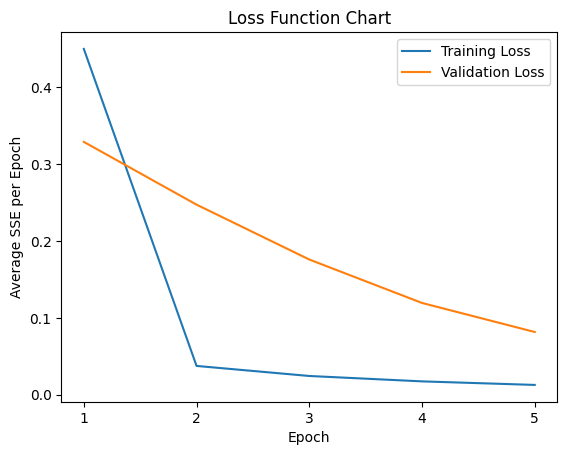

In [77]:
new_epochs = len(train_losses)
plt.plot(range(1, new_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, new_epochs + 1), val_losses, label='Validation Loss')
plt.title('Loss Function Chart')
plt.xlabel('Epoch')
plt.ylabel('Average SSE per Epoch')
plt.xticks(range(1, new_epochs + 1))
plt.legend()
plt.show()

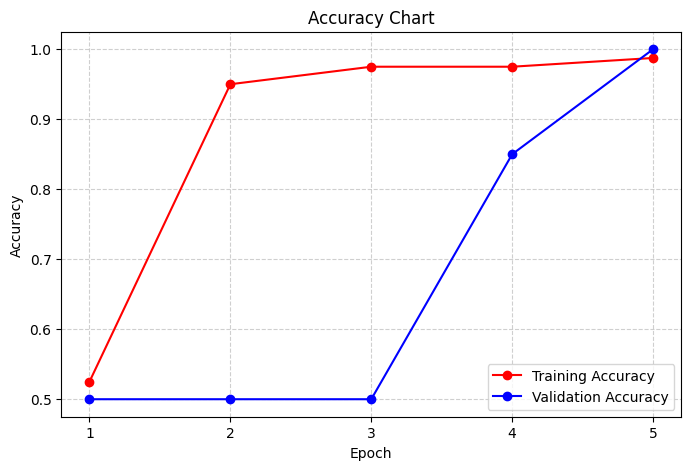

In [78]:
new_epochs = len(train_accs)
plt.figure(figsize=(8, 5))
plt.plot(range(1, new_epochs + 1), train_accs, marker='o', color='red', label='Training Accuracy')
plt.plot(range(1, new_epochs + 1), val_accs, marker='o', color='blue', label='Validation Accuracy')

plt.title('Accuracy Chart')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(1, new_epochs + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()